# Preliminary optical fuzzy c-means clustering at observed vegetation points

This notebook clusters the **45 Sentinel-2 harmonic intercept + amplitude features** already extracted at field-observed plot locations.

It deliberately does **not** read or mask full rasters. The input is the point-level supervised dataset produced by the field-vegetation × annual-K2 extraction workflow.

## Parallelism with the vegetation clustering

The optical analysis uses the same fuzzy c-means framework and the same four primary validity diagnostics used for the vegetation clustering:

- **PC — partition coefficient:** higher = crisper memberships
- **PE — partition entropy:** lower = less diffuse membership uncertainty
- **MCD — minimum centroid distance:** higher = stronger separation of the closest centroid pair
- **XB — Xie–Beni index:** lower = more compact / better-separated fuzzy partition

The FCM implementation, objective, best-of-20-restarts logic, and diagnostic definitions are kept parallel to the vegetation workflow.

The transformation differs only because the data domains differ:

- vegetation cover: closure + Hellinger transformation
- optical IA45 features: **column-wise z-score standardization**

The optical features are not compositional, so a Hellinger transform is not appropriate.

## Sweep

- `K = 7..14`
- `m = [1.05, 1.06, 1.07, 1.08, 1.09, 1.10, 1.15, 1.20, 1.25]`

Each `(K, m)` solution uses **20 random starts**, retaining the fit with the minimum FCM objective.

## Vegetation labels are external annotations only

Optical FCM is fit **once**, independently of vegetation labels. After each optical solution is hardened with `argmax(U)`, it is compared separately against:

- `parent_cluster`
- `state_id`

This preserves the optical clustering as an independent partition rather than tuning it to vegetation labels.

### ARI

**Adjusted Rand Index (ARI)** measures agreement between two hard partitions while correcting for agreement expected by chance. It is invariant to arbitrary cluster numbering.

- 1 = identical partitions
- 0 ≈ chance-level agreement
- values can be negative when agreement is worse than expected by chance

ARI is used for both restart stability and external optical–vegetation correspondence.

### NMI

**Normalized Mutual Information (NMI)** measures how much information one partition contains about another. It ranges from 0 to 1 and is invariant to arbitrary label numbering.

This notebook uses scikit-learn's arithmetic normalization. Unlike ARI, **NMI is not adjusted for chance**, so it can become more permissive as the number of clusters increases. ARI is therefore the primary external agreement statistic; NMI is supplementary.

Neither ARI nor NMI is used to choose `K` or `m`.


In [1]:
from pathlib import Path
from itertools import combinations
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from IPython.display import display

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)

# =============================================================================
# PATHS
# =============================================================================

INPUT_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)

OUTPUT_DIR = Path(
    r"A:\NCA_DATA\Validation\Optical_Clustering_Preliminary"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_CSV = OUTPUT_DIR / "Optical_FCM_K7to14_mSweep_metrics.csv"
HARD_LABELS_CSV = OUTPUT_DIR / "Optical_FCM_K7to14_hard_labels.csv"
MAX_MEMBERSHIP_CSV = OUTPUT_DIR / "Optical_FCM_K7to14_max_membership.csv"
SCALER_CSV = OUTPUT_DIR / "Optical_IA45_global_zscore_scaler.csv"

FIG_VALIDITY = OUTPUT_DIR / "Optical_FCM_PC_PE_MCD_XB_KxM.png"
FIG_STABILITY = OUTPUT_DIR / "Optical_FCM_occupancy_restartARI_KxM.png"
FIG_EXTERNAL = OUTPUT_DIR / "Optical_FCM_external_ARI_NMI_KxM.png"

# =============================================================================
# SWEEP SETTINGS
# =============================================================================

K_VALUES = list(range(7, 15))

M_VALUES = [
    1.05, 1.06, 1.07, 1.08, 1.09,
    1.10, 1.15, 1.20, 1.25,
]

N_STARTS = 20
RANDOM_STATE = 42
MAX_ITER = 300
TOL = 1e-5

EXPECTED_D = 45
EXPECTED_CURRENT_N = 479

print("Input:", INPUT_CSV)
print("Output directory:", OUTPUT_DIR)
print("K:", K_VALUES)
print("m:", M_VALUES)
print("K×m combinations:", len(K_VALUES) * len(M_VALUES))
print("Restarts per combination:", N_STARTS)


Input: A:\NCA_DATA\Validation\Supervised_State_Classification\FieldVeg_K2_IA45_Training.csv
Output directory: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary
K: [7, 8, 9, 10, 11, 12, 13, 14]
m: [1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.15, 1.2, 1.25]
K×m combinations: 72
Restarts per combination: 20


## 1. Load the point-level IA45 dataset

No raster masking or spatial filtering occurs here. The input rows are already the observed plot-year locations that survived the supervised extraction workflow.


In [2]:
# =============================================================================
# LOAD POINT-LEVEL SUPERVISED DATASET
# =============================================================================

if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Point-level IA45 training dataset not found:\n{INPUT_CSV}"
    )

df = pd.read_csv(INPUT_CSV, low_memory=False)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

intercept_cols = [
    c for c in df.columns
    if re.search(r"^(constant_|intercept_)", str(c), flags=re.IGNORECASE)
]

amplitude_cols = [
    c for c in df.columns
    if re.search(r"^(amp|amplitude)", str(c), flags=re.IGNORECASE)
]

IA_COLS = intercept_cols + amplitude_cols

print("Rows:", f"{len(df):,}")
print("Intercept features:", len(intercept_cols))
print("Amplitude features:", len(amplitude_cols))
print("IA dimensions:", len(IA_COLS))

if len(IA_COLS) != EXPECTED_D:
    raise ValueError(
        f"Expected {EXPECTED_D} IA features; found {len(IA_COLS)}.\n"
        f"Intercept example: {intercept_cols[:8]}\n"
        f"Amplitude example: {amplitude_cols[:8]}"
    )

if len(df) != EXPECTED_CURRENT_N:
    warnings.warn(
        f"Current point count is {len(df):,}, not the preliminary expected "
        f"{EXPECTED_CURRENT_N:,}. This is acceptable if the supervised dataset "
        "has intentionally changed."
    )

X_raw = (
    df[IA_COLS]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

bad_rows = X_raw.isna().any(axis=1)

if bad_rows.any():
    show_cols = [
        c for c in ["PlotID", "Year", "parent_cluster", "state_id"]
        if c in df.columns
    ]
    display(df.loc[bad_rows, show_cols].head(50))
    raise ValueError(
        f"{int(bad_rows.sum()):,} rows contain missing/non-finite IA45 values."
    )

if "Year" in df.columns:
    print("\nRows by year:")
    display(
        df.groupby("Year", as_index=False)
        .size()
        .rename(columns={"size": "n"})
    )

if "parent_cluster" in df.columns:
    print("\nVegetation parent classes represented:")
    display(
        df["parent_cluster"]
        .value_counts(dropna=False)
        .sort_index()
        .rename("n")
        .to_frame()
    )

if "state_id" in df.columns:
    print("\nVegetation subcluster/state classes represented:")
    display(
        df["state_id"]
        .astype("string")
        .value_counts(dropna=False)
        .sort_index()
        .rename("n")
        .to_frame()
    )


Rows: 479
Intercept features: 15
Amplitude features: 30
IA dimensions: 45

Rows by year:


,Year,n
0,2016,255
1,2018,106
2,2025,118



Vegetation parent classes represented:


,n
parent_cluster,
1,83
2,59
3,78
4,82
5,74
6,51
7,32
8,20



Vegetation subcluster/state classes represented:


,n
state_id,
1.1,83
2.1,19
2.2,26
2.3,14
3.1,10
3.2,31
3.3,14
3.4,7
3.5,13


## 2. Standardize IA45 once across the pooled observed point-year matrix

The scaler is fit once to the full observed IA45 matrix and then frozen.

This puts all 45 harmonic features on the same Euclidean scale while retaining their relative geometry. The same saved scaler must later be applied to unobserved pixels before computing distance to the selected optical centroids.


In [3]:
# =============================================================================
# GLOBAL IA45 Z-SCORE STANDARDIZATION
# =============================================================================

scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(X_raw.to_numpy(dtype=float))

if not np.isfinite(X).all():
    raise RuntimeError("Standardized IA45 matrix contains non-finite values.")

if X.shape[1] != EXPECTED_D:
    raise RuntimeError(
        f"Expected D={EXPECTED_D}; standardized matrix has D={X.shape[1]}."
    )

scaler_table = pd.DataFrame({
    "feature": IA_COLS,
    "mean": scaler.mean_,
    "scale": scaler.scale_,
})

scaler_table.to_csv(SCALER_CSV, index=False)

print("X shape:", X.shape)
print("Mean absolute standardized feature mean:", np.abs(X.mean(axis=0)).mean())
print("Mean standardized feature SD:", X.std(axis=0, ddof=0).mean())
print("Wrote scaler:", SCALER_CSV)


X shape: (479, 45)
Mean absolute standardized feature mean: 1.8977061989927749e-16
Mean standardized feature SD: 1.0
Wrote scaler: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Optical_IA45_global_zscore_scaler.csv


## 3. Fuzzy c-means implementation

The objective and update equations are the same as in the vegetation FCM workflow.

Because this sweep intentionally explores values very close to `m = 1`, the membership update is evaluated in **log space**. This is mathematically equivalent to the standard power update but prevents numerical overflow at exponents such as `-40` for `m = 1.05`.

For each `(K, m)`, 20 starts are fit and the smallest-objective solution is retained.


In [4]:
# =============================================================================
# FUZZY C-MEANS HELPERS
# =============================================================================

def init_membership(n: int, k: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    U = rng.random((n, k))
    return U / U.sum(axis=1, keepdims=True)


def membership_from_distances(D: np.ndarray, m: float) -> np.ndarray:
    """
    Numerically stable form of the standard FCM membership update.
    """

    if m <= 1:
        raise ValueError("FCM requires m > 1.")

    eps = 1e-12
    D = np.maximum(D, eps)

    power = -2.0 / (m - 1.0)

    log_w = power * np.log(D)
    log_w = log_w - np.max(log_w, axis=1, keepdims=True)

    W = np.exp(log_w)
    return W / W.sum(axis=1, keepdims=True)


def fuzzy_cmeans(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    max_iter: int = 300,
    tol: float = 1e-5,
    seed: int = 42,
):
    if m <= 1:
        raise ValueError("FCM requires m > 1.")

    n = X.shape[0]
    eps = 1e-12

    U = init_membership(n, k, seed)
    converged = False

    for iteration in range(1, max_iter + 1):
        U_old = U.copy()

        Um = U ** m
        centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)

        D = cdist(X, centers, metric="euclidean")
        U = membership_from_distances(D, m)

        if np.max(np.abs(U - U_old)) < tol:
            converged = True
            break

    Um = U ** m
    centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)

    D = np.maximum(
        cdist(X, centers, metric="euclidean"),
        eps,
    )

    objective = float(np.sum((U ** m) * (D ** 2)))

    return {
        "centers": centers,
        "U": U,
        "objective": objective,
        "iterations": iteration,
        "converged": converged,
        "seed": seed,
    }


def fit_fcm_restarts(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    n_starts: int = 20,
    random_state: int = 42,
    max_iter: int = 300,
    tol: float = 1e-5,
):
    fits = []

    for seed in range(random_state, random_state + n_starts):
        fits.append(
            fuzzy_cmeans(
                X=X,
                k=k,
                m=m,
                max_iter=max_iter,
                tol=tol,
                seed=seed,
            )
        )

    best = min(fits, key=lambda z: z["objective"])
    return best, fits


## 4. Validity, occupancy, stability, and correspondence metrics

The four primary internal diagnostics exactly parallel the vegetation clustering:

- **PC:** higher is crisper
- **PE:** lower is less diffuse
- **MCD:** higher means the closest centroid pair is farther apart
- **XB:** lower means smaller fuzzy dispersion relative to centroid separation

Additional diagnostics:

- minimum and maximum hard-cluster occupancy
- restart ARI among the 20 random starts
- ARI/NMI against vegetation parents
- ARI/NMI against vegetation subclusters

External vegetation agreement is diagnostic only and is not used to select the optical partition.


In [5]:
# =============================================================================
# DIAGNOSTIC METRICS
# =============================================================================

def fcm_metrics(fit: dict) -> dict:
    U = fit["U"]
    centers = fit["centers"]

    n, k = U.shape
    eps = 1e-12

    pc = float(np.sum(U ** 2) / n)
    mpc = float((pc - (1.0 / k)) / (1.0 - (1.0 / k)))
    pe = float(-np.sum(U * np.log(np.maximum(U, eps))) / n)

    center_distances = pdist(centers, metric="euclidean")
    mcd = float(center_distances.min())

    xb = float(
        fit["objective"]
        / (n * max(mcd ** 2, eps))
    )

    sorted_u = np.sort(U, axis=1)
    max_u = sorted_u[:, -1]
    margin = sorted_u[:, -1] - sorted_u[:, -2]

    hard = np.argmax(U, axis=1)
    occupancy = np.bincount(hard, minlength=k)

    return {
        "PC": pc,
        "MPC": mpc,
        "PE": pe,
        "XB": xb,
        "MCD": mcd,
        "mean_max_membership": float(max_u.mean()),
        "median_max_membership": float(np.median(max_u)),
        "mean_membership_margin": float(margin.mean()),
        "min_occupancy_n": int(occupancy.min()),
        "max_occupancy_n": int(occupancy.max()),
        "min_occupancy_fraction": float(occupancy.min() / n),
        "max_occupancy_fraction": float(occupancy.max() / n),
    }


def restart_stability(fits: list) -> dict:
    hard_labels = [
        np.argmax(fit["U"], axis=1)
        for fit in fits
    ]

    aris = [
        adjusted_rand_score(hard_labels[i], hard_labels[j])
        for i, j in combinations(range(len(hard_labels)), 2)
    ]

    if not aris:
        return {
            "restart_ARI_mean": np.nan,
            "restart_ARI_median": np.nan,
            "restart_ARI_min": np.nan,
        }

    aris = np.asarray(aris, dtype=float)

    return {
        "restart_ARI_mean": float(np.mean(aris)),
        "restart_ARI_median": float(np.median(aris)),
        "restart_ARI_min": float(np.min(aris)),
    }


def external_partition_metrics(reference, optical_hard, prefix):
    ref = pd.Series(reference)
    mask = ref.notna().to_numpy()

    n_used = int(mask.sum())

    if n_used < 2:
        return {
            f"n_{prefix}": n_used,
            f"ARI_{prefix}": np.nan,
            f"NMI_{prefix}": np.nan,
        }

    ref_valid = ref.loc[mask].astype(str).to_numpy()
    optical_valid = np.asarray(optical_hard)[mask]

    if (
        pd.Series(ref_valid).nunique() < 2
        or pd.Series(optical_valid).nunique() < 2
    ):
        return {
            f"n_{prefix}": n_used,
            f"ARI_{prefix}": np.nan,
            f"NMI_{prefix}": np.nan,
        }

    return {
        f"n_{prefix}": n_used,
        f"ARI_{prefix}": float(
            adjusted_rand_score(ref_valid, optical_valid)
        ),
        f"NMI_{prefix}": float(
            normalized_mutual_info_score(
                ref_valid,
                optical_valid,
                average_method="arithmetic",
            )
        ),
    }


## 5. Run the full `K × m` sweep

There are 72 candidate `(K, m)` combinations. Each one is fit from 20 starts.

The notebook retains the best fit for every combination in memory and writes the full metric table, hard labels, and maximum memberships to disk.


In [6]:
# =============================================================================
# K × m OPTICAL FCM SWEEP
# =============================================================================

sweep_rows = []
best_solutions = {}

base_cols = [
    c for c in [
        "PlotID",
        "Year",
        "Easting",
        "Northing",
        "parent_cluster",
        "state_id",
    ]
    if c in df.columns
]

hard_label_table = df[base_cols].copy()

max_membership_table = df[
    [
        c for c in [
            "PlotID",
            "Year",
            "Easting",
            "Northing",
        ]
        if c in df.columns
    ]
].copy()


for m in M_VALUES:

    print("\n" + "=" * 80)
    print(f"m = {m:.2f}")
    print("=" * 80)

    for k in K_VALUES:

        best_fit, all_fits = fit_fcm_restarts(
            X=X,
            k=k,
            m=m,
            n_starts=N_STARTS,
            random_state=RANDOM_STATE,
            max_iter=MAX_ITER,
            tol=TOL,
        )

        best_solutions[(int(k), float(m))] = best_fit

        metrics = fcm_metrics(best_fit)
        stability = restart_stability(all_fits)

        hard = np.argmax(best_fit["U"], axis=1) + 1
        max_u = np.max(best_fit["U"], axis=1)

        parent_metrics = {}
        if "parent_cluster" in df.columns:
            parent_metrics = external_partition_metrics(
                df["parent_cluster"],
                hard,
                "parent",
            )

        subcluster_metrics = {}
        if "state_id" in df.columns:
            subcluster_metrics = external_partition_metrics(
                df["state_id"],
                hard,
                "subcluster",
            )

        sweep_rows.append({
            "K": int(k),
            "m": float(m),
            "best_seed": int(best_fit["seed"]),
            "objective": float(best_fit["objective"]),
            "iterations": int(best_fit["iterations"]),
            "converged": bool(best_fit["converged"]),
            **metrics,
            **stability,
            **parent_metrics,
            **subcluster_metrics,
        })

        tag = (
            f"K{k:02d}_m"
            + f"{m:.2f}".replace(".", "p")
        )

        hard_label_table[tag] = hard
        max_membership_table[tag] = max_u

        print(
            f"K={k:2d} | "
            f"PC={metrics['PC']:.4f} | "
            f"PE={metrics['PE']:.4f} | "
            f"MCD={metrics['MCD']:.4f} | "
            f"XB={metrics['XB']:.4f} | "
            f"occ={metrics['min_occupancy_n']:3d}"
            f"..{metrics['max_occupancy_n']:3d} | "
            f"restart ARI={stability['restart_ARI_mean']:.3f}"
        )


sweep = (
    pd.DataFrame(sweep_rows)
    .sort_values(["m", "K"])
    .reset_index(drop=True)
)

sweep.to_csv(METRICS_CSV, index=False)
hard_label_table.to_csv(HARD_LABELS_CSV, index=False)
max_membership_table.to_csv(MAX_MEMBERSHIP_CSV, index=False)

print("\nWrote:", METRICS_CSV)
print("Wrote:", HARD_LABELS_CSV)
print("Wrote:", MAX_MEMBERSHIP_CSV)



m = 1.05
K= 7 | PC=0.9751 | PE=0.0445 | MCD=3.9391 | XB=1.2288 | occ= 32..113 | restart ARI=0.876
K= 8 | PC=0.9738 | PE=0.0464 | MCD=3.9423 | XB=1.1577 | occ=  8.. 96 | restart ARI=0.801
K= 9 | PC=0.9747 | PE=0.0458 | MCD=3.9807 | XB=1.0934 | occ=  8.. 95 | restart ARI=0.772
K=10 | PC=0.9745 | PE=0.0463 | MCD=3.9941 | XB=1.0475 | occ=  8.. 84 | restart ARI=0.728
K=11 | PC=0.9778 | PE=0.0413 | MCD=3.9404 | XB=1.0350 | occ=  1.. 84 | restart ARI=0.672
K=12 | PC=0.9676 | PE=0.0574 | MCD=3.4631 | XB=1.3043 | occ=  1.. 75 | restart ARI=0.648
K=13 | PC=0.9784 | PE=0.0418 | MCD=3.3134 | XB=1.3828 | occ=  1.. 70 | restart ARI=0.675
K=14 | PC=0.9696 | PE=0.0549 | MCD=3.6895 | XB=1.0936 | occ=  1.. 65 | restart ARI=0.629

m = 1.06
K= 7 | PC=0.9668 | PE=0.0583 | MCD=3.9343 | XB=1.2307 | occ= 32..113 | restart ARI=0.905
K= 8 | PC=0.9652 | PE=0.0607 | MCD=3.9404 | XB=1.1578 | occ=  8.. 96 | restart ARI=0.820
K= 9 | PC=0.9660 | PE=0.0613 | MCD=3.9793 | XB=1.0932 | occ=  8.. 95 | restart ARI=0.780
K

## 6. Full sweep table


In [7]:
# =============================================================================
# SWEEP TABLE
# =============================================================================

display_cols = [
    "K",
    "m",
    "objective",
    "PC",
    "PE",
    "MCD",
    "XB",
    "min_occupancy_n",
    "max_occupancy_n",
    "min_occupancy_fraction",
    "max_occupancy_fraction",
    "restart_ARI_mean",
    "restart_ARI_min",
    "ARI_parent",
    "NMI_parent",
    "ARI_subcluster",
    "NMI_subcluster",
]

display_cols = [c for c in display_cols if c in sweep.columns]

display(
    sweep[display_cols].style
    .format({
        "m": "{:.2f}",
        "objective": "{:.5f}",
        "PC": "{:.4f}",
        "PE": "{:.4f}",
        "MCD": "{:.4f}",
        "XB": "{:.4f}",
        "min_occupancy_fraction": "{:.3f}",
        "max_occupancy_fraction": "{:.3f}",
        "restart_ARI_mean": "{:.3f}",
        "restart_ARI_min": "{:.3f}",
        "ARI_parent": "{:.3f}",
        "NMI_parent": "{:.3f}",
        "ARI_subcluster": "{:.3f}",
        "NMI_subcluster": "{:.3f}",
    })
    .hide(axis="index")
)


K,m,objective,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,min_occupancy_fraction,max_occupancy_fraction,restart_ARI_mean,restart_ARI_min,ARI_parent,NMI_parent,ARI_subcluster,NMI_subcluster
7,1.05,9132.91299,0.9751,0.0445,3.9391,1.2288,32,113,0.067,0.236,0.876,0.625,0.090,0.196,0.070,0.219
8,1.05,8618.89812,0.9738,0.0464,3.9423,1.1577,8,96,0.017,0.200,0.801,0.506,0.091,0.195,0.074,0.217
9,1.05,8298.92427,0.9747,0.0458,3.9807,1.0934,8,95,0.017,0.198,0.772,0.554,0.090,0.200,0.080,0.230
10,1.05,8003.96352,0.9745,0.0463,3.9941,1.0475,8,84,0.017,0.175,0.728,0.532,0.091,0.214,0.079,0.246
11,1.05,7697.56734,0.9778,0.0413,3.9404,1.0350,1,84,0.002,0.175,0.672,0.440,0.091,0.215,0.079,0.247
12,1.05,7492.48911,0.9676,0.0574,3.4631,1.3043,1,75,0.002,0.157,0.648,0.469,0.088,0.207,0.081,0.246
13,1.05,7271.64867,0.9784,0.0418,3.3134,1.3828,1,70,0.002,0.146,0.675,0.483,0.083,0.212,0.077,0.256
14,1.05,7130.71776,0.9696,0.0549,3.6895,1.0936,1,65,0.002,0.136,0.629,0.448,0.086,0.212,0.082,0.257
7,1.06,9124.76005,0.9668,0.0583,3.9343,1.2307,32,113,0.067,0.236,0.905,0.632,0.090,0.196,0.070,0.219
8,1.06,8611.39369,0.9652,0.0607,3.9404,1.1578,8,96,0.017,0.200,0.820,0.436,0.091,0.195,0.074,0.217


## 7. Metric matrices

These are the same `m × K` style summaries used during vegetation FCM exploration.


In [8]:
# =============================================================================
# PIVOT TABLES
# =============================================================================

for metric in [
    "PC",
    "PE",
    "MCD",
    "XB",
    "min_occupancy_n",
    "max_occupancy_n",
    "restart_ARI_mean",
    "ARI_parent",
    "NMI_parent",
    "ARI_subcluster",
    "NMI_subcluster",
]:

    if metric not in sweep.columns:
        continue

    print("\n", metric)

    pivot = sweep.pivot(
        index="m",
        columns="K",
        values=metric,
    )

    display(pivot.round(4))



 PC


K,7,8,9,10,11,12,13,14
m,,,,,,,,
1.05,0.9751,0.9738,0.9747,0.9745,0.9778,0.9676,0.9784,0.9696
1.06,0.9668,0.9652,0.9660,0.9658,0.9697,0.9571,0.9641,0.9543
1.07,0.9587,0.9565,0.9572,0.9569,0.9612,0.9472,0.9536,0.9469
1.08,0.9508,0.9481,0.9483,0.9477,0.9522,0.9517,0.9460,0.9407
1.09,0.9429,0.9400,0.9393,0.9385,0.9429,0.9404,0.9296,0.9242
1.10,0.9349,0.9318,0.9305,0.9292,0.9332,0.9143,0.9186,0.9129
1.15,0.8915,0.8850,0.8811,0.8720,0.8646,0.8513,0.8512,0.8521
1.20,0.8412,0.8299,0.8226,0.8119,0.8012,0.7813,0.7755,0.7688
1.25,0.7842,0.7697,0.7581,0.7438,0.7305,0.7073,0.6959,0.6878



 PE


K,7,8,9,10,11,12,13,14
m,,,,,,,,
1.05,0.0445,0.0464,0.0458,0.0463,0.0413,0.0574,0.0418,0.0549
1.06,0.0583,0.0607,0.0613,0.0620,0.0562,0.0759,0.0663,0.0811
1.07,0.0722,0.0755,0.0772,0.0782,0.0718,0.0942,0.0856,0.0943
1.08,0.0863,0.0905,0.0935,0.0949,0.0884,0.0915,0.1009,0.1096
1.09,0.1008,0.1057,0.1102,0.1121,0.1058,0.1121,0.1298,0.1360
1.10,0.1160,0.1216,0.1274,0.1298,0.1240,0.1568,0.1499,0.1575
1.15,0.2024,0.2148,0.2269,0.2450,0.2579,0.2833,0.2862,0.2851
1.20,0.3081,0.3289,0.3502,0.3765,0.3962,0.4351,0.4499,0.4688
1.25,0.4317,0.4592,0.4923,0.5294,0.5575,0.6065,0.6369,0.6581



 MCD


...

K,7,8,9,10,11,12,13,14
m,,,,,,,,
1.05,0.1955,0.1953,0.1997,0.2139,0.2150,0.2075,0.2121,0.2117
1.06,0.1955,0.1953,0.1997,0.2139,0.2150,0.2055,0.2033,0.2001
1.07,0.1941,0.1946,0.1997,0.2160,0.2169,0.2154,0.2012,0.2049
1.08,0.1941,0.1941,0.2041,0.2160,0.2153,0.2050,0.2085,0.2168
1.09,0.1935,0.1930,0.2036,0.2155,0.2153,0.2050,0.2015,0.2043
1.10,0.1935,0.1911,0.2036,0.2155,0.2153,0.1906,0.2023,0.2021
1.15,0.1907,0.1871,0.2030,0.2216,0.2142,0.2023,0.2050,0.2060
1.20,0.1892,0.1844,0.2045,0.2207,0.2126,0.2044,0.2075,0.2225
1.25,0.1817,0.1851,0.1961,0.2168,0.2144,0.2019,0.2055,0.2140



 ARI_subcluster


K,7,8,9,10,11,12,13,14
m,,,,,,,,
1.05,0.0702,0.0741,0.0804,0.0791,0.0794,0.0814,0.0766,0.0821
1.06,0.0702,0.0741,0.0804,0.0791,0.0794,0.0825,0.0639,0.0702
1.07,0.0685,0.0732,0.0804,0.0796,0.0800,0.0849,0.0635,0.0648
1.08,0.0685,0.0722,0.0821,0.0796,0.0793,0.0696,0.0751,0.0664
1.09,0.0678,0.0728,0.0814,0.0789,0.0793,0.0696,0.0656,0.0667
1.10,0.0678,0.0725,0.0814,0.0789,0.0793,0.0655,0.0635,0.0651
1.15,0.0658,0.0735,0.0823,0.0874,0.0743,0.0673,0.0659,0.0655
1.20,0.0661,0.0750,0.0843,0.0903,0.0740,0.0652,0.0664,0.0687
1.25,0.0679,0.0758,0.0835,0.0888,0.0738,0.0649,0.0670,0.0689



 NMI_subcluster


K,7,8,9,10,11,12,13,14
m,,,,,,,,
1.05,0.2189,0.2165,0.2301,0.2458,0.2475,0.2459,0.2559,0.2573
1.06,0.2189,0.2165,0.2301,0.2458,0.2475,0.2450,0.2471,0.2511
1.07,0.2177,0.2159,0.2301,0.2464,0.2481,0.2520,0.2473,0.2520
1.08,0.2177,0.2155,0.2322,0.2445,0.2454,0.2406,0.2531,0.2602
1.09,0.2172,0.2151,0.2313,0.2436,0.2454,0.2406,0.2493,0.2490
1.10,0.2172,0.2140,0.2313,0.2436,0.2454,0.2343,0.2474,0.2470
1.15,0.2123,0.2138,0.2324,0.2518,0.2512,0.2446,0.2534,0.2532
1.20,0.2115,0.2112,0.2333,0.2523,0.2506,0.2461,0.2528,0.2683
1.25,0.2075,0.2115,0.2277,0.2483,0.2497,0.2420,0.2517,0.2671


## 8. Core four-panel validity figure — PC, PE, MCD, XB

This is the direct optical analogue of the vegetation FCM diagnostic figure.

Each line is one fuzzifier value; `K` varies along the x-axis. No candidate is highlighted automatically because model selection is deliberately deferred until the full geometry is inspected.


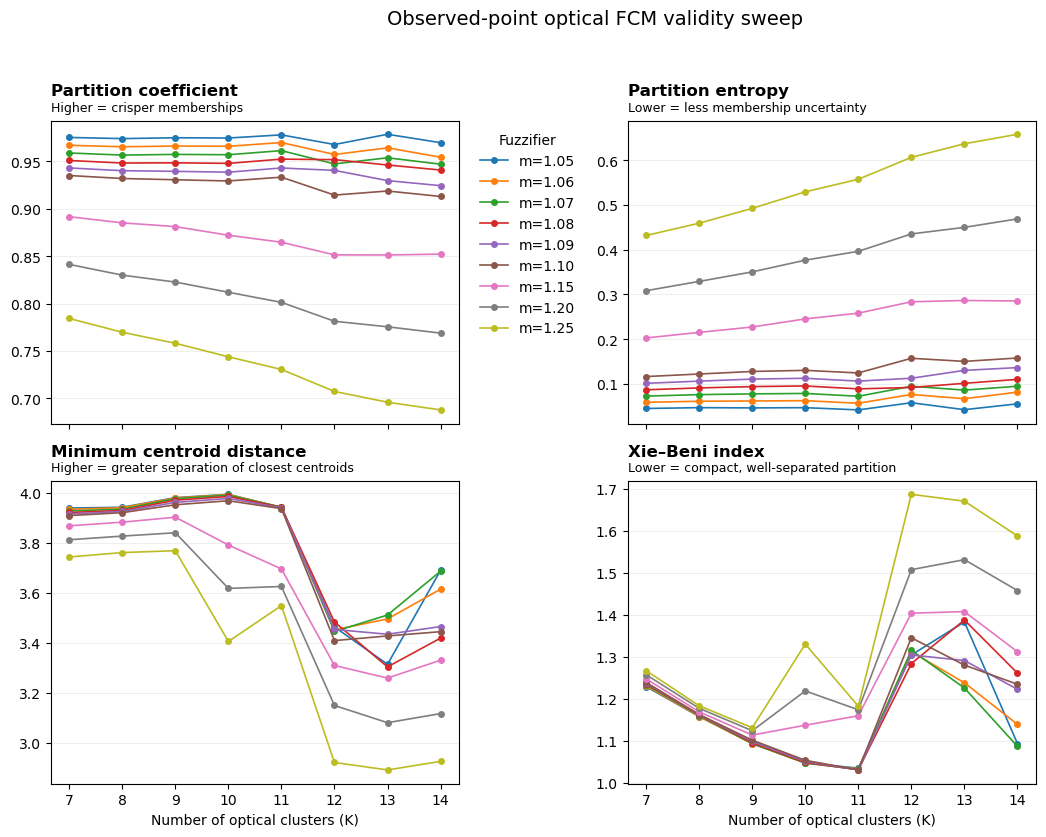

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Optical_FCM_PC_PE_MCD_XB_KxM.png


In [15]:
# =============================================================================
# FOUR-PANEL INTERNAL FCM DIAGNOSTIC FIGURE
# =============================================================================

def plot_fcm_indices_four_panel(
    diagnostics,
    selected_k=None,
    selected_m=None,
    figsize=(12, 8.5),
):

    req = {"m", "K", "PC", "PE", "MCD", "XB"}
    missing = req - set(diagnostics.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
        sharex=True,
    )

    axes = axes.ravel()

    specs = [
        (
            "PC",
            "Partition coefficient",
            "Higher = crisper memberships",
        ),
        (
            "PE",
            "Partition entropy",
            "Lower = less membership uncertainty",
        ),
        (
            "MCD",
            "Minimum centroid distance",
            "Higher = greater separation of closest centroids",
        ),
        (
            "XB",
            "Xie–Beni index",
            "Lower = compact, well-separated partition",
        ),
    ]

    for ax, (col, title, subtitle) in zip(axes, specs):

        for m in M_VALUES:

            sub = (
                diagnostics.loc[
                    np.isclose(
                        diagnostics["m"].astype(float),
                        float(m),
                    )
                ]
                .sort_values("K")
            )

            ax.plot(
                sub["K"],
                sub[col],
                marker="o",
                linewidth=1.2,
                markersize=4,
                label=f"m={m:.2f}",
            )

        if selected_k is not None and selected_m is not None:

            hit = diagnostics.loc[
                diagnostics["K"].eq(int(selected_k))
                &
                np.isclose(
                    diagnostics["m"].astype(float),
                    float(selected_m),
                )
            ]

            if len(hit) == 1:
                ax.scatter(
                    hit["K"].iloc[0],
                    hit[col].iloc[0],
                    s=70,
                    zorder=5,
                )

        # Main title
        ax.set_title(
            title,
            loc="left",
            fontsize=12,
            fontweight="bold",
            pad=18,
        )

        # Subtitle positioned just inside the axes, below the title
        ax.text(
            0.0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            fontsize=9,
            ha="left",
            va="bottom",
        )

        ax.set_xticks(K_VALUES)
        ax.grid(axis="y", alpha=0.2)

    axes[2].set_xlabel("Number of optical clusters (K)")
    axes[3].set_xlabel("Number of optical clusters (K)")

    axes[0].legend(
        title="Fuzzifier",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        frameon=False,
    )

    fig.suptitle(
        "Observed-point optical FCM validity sweep",
        fontsize=14,
        y=0.98,
    )

    fig.tight_layout(rect=[0, 0, 0.88, 0.95])

    return fig


fig = plot_fcm_indices_four_panel(sweep)

fig.savefig(
    FIG_VALIDITY,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", FIG_VALIDITY)

## 9. Occupancy and restart stability

The occupancy diagnostics identify solutions that create tiny or dominant hard clusters.

Restart ARI asks a separate question: **does the same `(K, m)` geometry reappear from different initial membership matrices?**


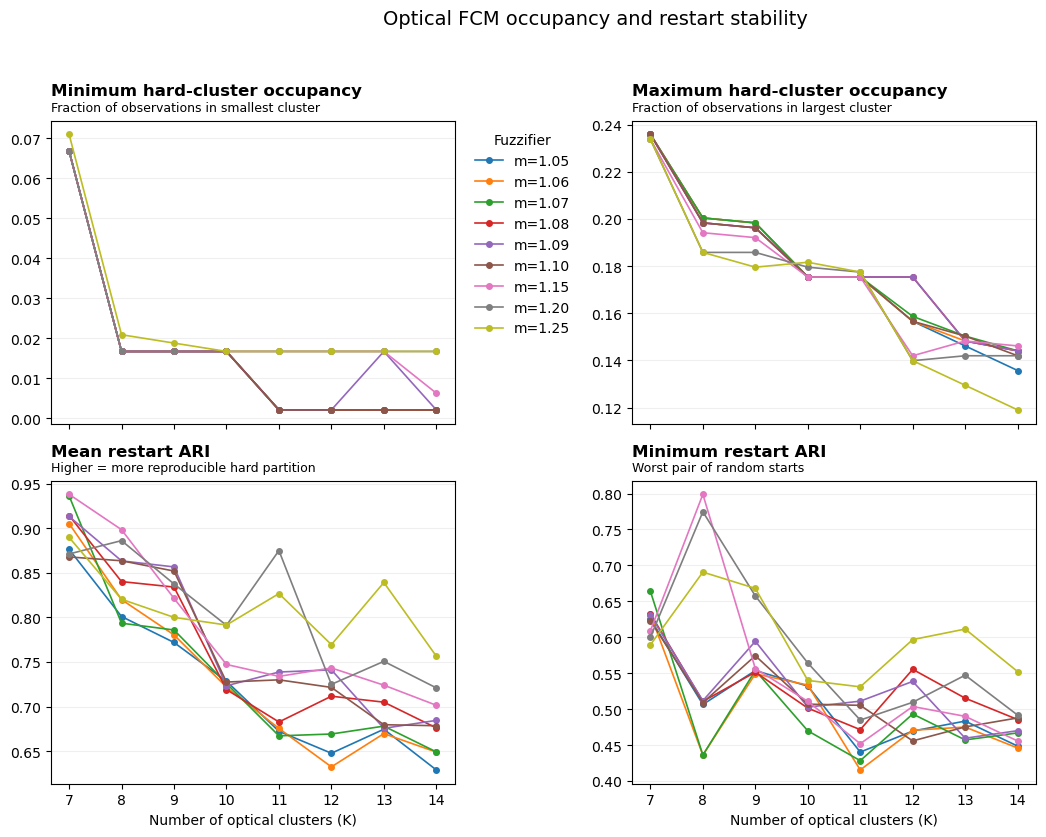

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Optical_FCM_occupancy_restartARI_KxM.png


In [16]:
# =============================================================================
# OCCUPANCY + RESTART STABILITY FIGURE
# =============================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8.5),
    sharex=True,
)

axes = axes.ravel()

specs = [
    (
        "min_occupancy_fraction",
        "Minimum hard-cluster occupancy",
        "Fraction of observations in smallest cluster",
    ),
    (
        "max_occupancy_fraction",
        "Maximum hard-cluster occupancy",
        "Fraction of observations in largest cluster",
    ),
    (
        "restart_ARI_mean",
        "Mean restart ARI",
        "Higher = more reproducible hard partition",
    ),
    (
        "restart_ARI_min",
        "Minimum restart ARI",
        "Worst pair of random starts",
    ),
]

for ax, (col, title, subtitle) in zip(axes, specs):

    for m in M_VALUES:

        sub = (
            sweep.loc[
                np.isclose(
                    sweep["m"].astype(float),
                    float(m),
                )
            ]
            .sort_values("K")
        )

        ax.plot(
            sub["K"],
            sub[col],
            marker="o",
            linewidth=1.2,
            markersize=4,
            label=f"m={m:.2f}",
        )

    # Main subplot title
    ax.set_title(
        title,
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=18,
    )

    # Subtitle
    ax.text(
        0.0,
        1.02,
        subtitle,
        transform=ax.transAxes,
        fontsize=9,
        ha="left",
        va="bottom",
    )

    ax.set_xticks(K_VALUES)
    ax.grid(axis="y", alpha=0.2)

axes[2].set_xlabel("Number of optical clusters (K)")
axes[3].set_xlabel("Number of optical clusters (K)")

axes[0].legend(
    title="Fuzzifier",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
)

fig.suptitle(
    "Optical FCM occupancy and restart stability",
    fontsize=14,
    y=0.98,
)

fig.tight_layout(
    rect=[0, 0, 0.88, 0.95]
)

fig.savefig(
    FIG_STABILITY,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Wrote:", FIG_STABILITY)

## 10. External optical ↔ vegetation correspondence

These panels do **not** participate in optical cluster selection.

They ask how much each independently derived optical hard partition corresponds to the two vegetation resolutions:

- parent clusters
- subclusters / final states

ARI is the primary statistic because it adjusts for chance. NMI is shown as a supplementary information-overlap measure.


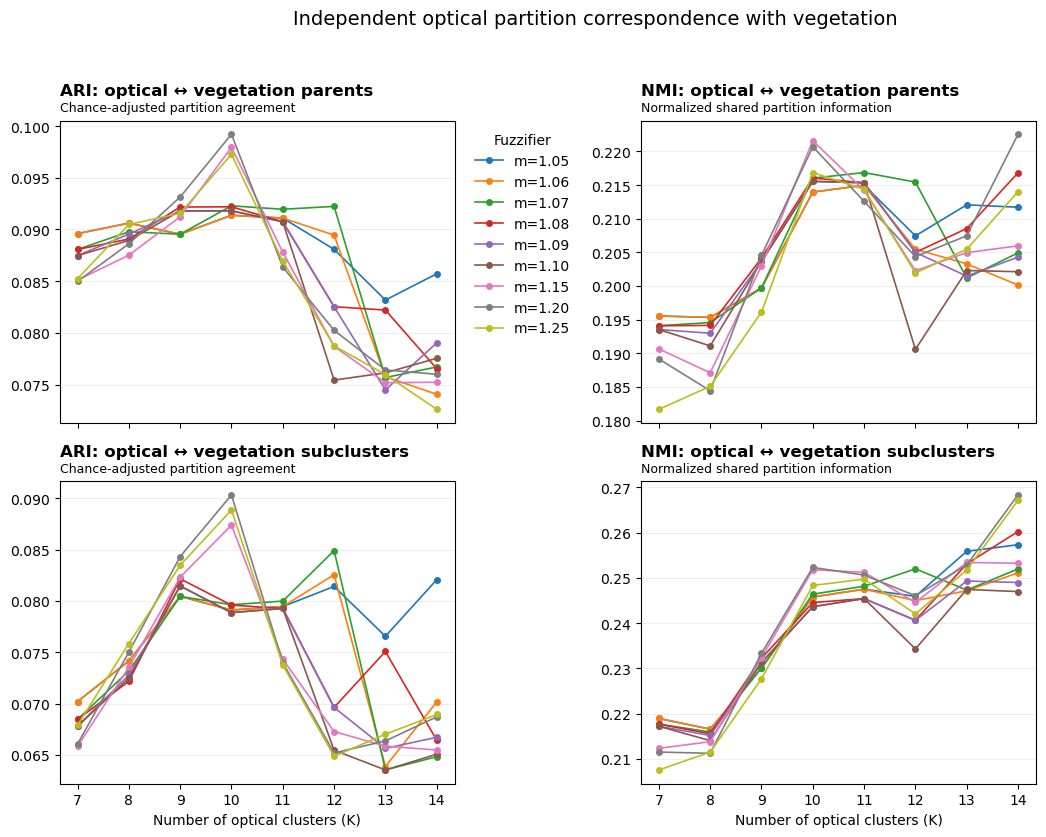

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Optical_FCM_external_ARI_NMI_KxM.png


In [17]:
# =============================================================================
# EXTERNAL CORRESPONDENCE FIGURE
# =============================================================================

external_specs = [
    (
        "ARI_parent",
        "ARI: optical ↔ vegetation parents",
        "Chance-adjusted partition agreement",
    ),
    (
        "NMI_parent",
        "NMI: optical ↔ vegetation parents",
        "Normalized shared partition information",
    ),
    (
        "ARI_subcluster",
        "ARI: optical ↔ vegetation subclusters",
        "Chance-adjusted partition agreement",
    ),
    (
        "NMI_subcluster",
        "NMI: optical ↔ vegetation subclusters",
        "Normalized shared partition information",
    ),
]

available_external_specs = [
    spec for spec in external_specs
    if spec[0] in sweep.columns
]

if len(available_external_specs) == 4:

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8.5),
        sharex=True,
    )

    axes = axes.ravel()

    for ax, (col, title, subtitle) in zip(
        axes,
        available_external_specs,
    ):

        for m in M_VALUES:

            sub = (
                sweep.loc[
                    np.isclose(
                        sweep["m"].astype(float),
                        float(m),
                    )
                ]
                .sort_values("K")
            )

            ax.plot(
                sub["K"],
                sub[col],
                marker="o",
                linewidth=1.2,
                markersize=4,
                label=f"m={m:.2f}",
            )

        # -------------------------------------------------------------
        # SUBPLOT TITLE
        # -------------------------------------------------------------

        ax.set_title(
            title,
            loc="left",
            fontsize=12,
            fontweight="bold",
            pad=18,
        )

        # -------------------------------------------------------------
        # SUBTITLE
        # -------------------------------------------------------------

        ax.text(
            0.0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            fontsize=9,
            ha="left",
            va="bottom",
        )

        ax.set_xticks(K_VALUES)
        ax.grid(axis="y", alpha=0.2)

    axes[2].set_xlabel(
        "Number of optical clusters (K)"
    )

    axes[3].set_xlabel(
        "Number of optical clusters (K)"
    )

    axes[0].legend(
        title="Fuzzifier",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        frameon=False,
    )

    # -------------------------------------------------------------
    # FIGURE TITLE
    # -------------------------------------------------------------

    fig.suptitle(
        "Independent optical partition correspondence with vegetation",
        fontsize=14,
        y=0.98,
    )

    # Leave room on right for legend and at top for suptitle.
    fig.tight_layout(
        rect=[0, 0, 0.88, 0.95]
    )

    fig.savefig(
        FIG_EXTERNAL,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Wrote:", FIG_EXTERNAL)

else:

    print(
        "Parent and/or subcluster vegetation labels were not available; "
        "external correspondence figure skipped."
    )

## 11. Inspect diagnostic extremes without selecting automatically

These are diagnostics, not automatic winners.

- PC and PE will generally favor lower `m` because low `m` makes memberships intrinsically crisper.
- XB and MCD provide more direct information about centroid geometry.
- occupancy guards against pathological partitions.
- restart ARI tests reproducibility.
- vegetation ARI/NMI are correspondence outcomes, not tuning criteria.


In [12]:
# =============================================================================
# DIAGNOSTIC EXTREMES
# =============================================================================

def show_top(metric, ascending, n=12):

    if metric not in sweep.columns:
        return

    print(
        "\n",
        metric,
        "—",
        "lower values first" if ascending else "higher values first",
    )

    cols = [
        c for c in [
            "K",
            "m",
            "PC",
            "PE",
            "MCD",
            "XB",
            "min_occupancy_n",
            "max_occupancy_n",
            "restart_ARI_mean",
            "ARI_parent",
            "ARI_subcluster",
        ]
        if c in sweep.columns
    ]

    display(
        sweep.sort_values(
            metric,
            ascending=ascending,
        )[cols].head(n)
    )


show_top("PC", ascending=False)
show_top("PE", ascending=True)
show_top("MCD", ascending=False)
show_top("XB", ascending=True)
show_top("restart_ARI_mean", ascending=False)



 PC — higher values first


,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,ARI_parent,ARI_subcluster
6,13,1.05,0.978411,0.041844,3.313421,1.382751,1,70,0.674601,0.083172,0.076553
4,11,1.05,0.977777,0.041338,3.940406,1.034990,1,84,0.672291,0.091101,0.079447
0,7,1.05,0.975064,0.044502,3.939149,1.228765,32,113,0.876389,0.089598,0.070202
2,9,1.05,0.974737,0.045797,3.980687,1.093378,8,95,0.771897,0.089543,0.080435
3,10,1.05,0.974473,0.046321,3.994082,1.047455,8,84,0.728445,0.091374,0.079104
1,8,1.05,0.973845,0.046373,3.942349,1.157727,8,96,0.801023,0.090614,0.074150
12,11,1.06,0.969687,0.056171,3.942321,1.033235,1,84,0.675460,0.091101,0.079447
7,14,1.05,0.969564,0.054865,3.689543,1.093585,1,65,0.628943,0.085716,0.082062
5,12,1.05,0.967627,0.057367,3.463088,1.304258,1,75,0.647663,0.088078,0.081402
8,7,1.06,0.966800,0.058313,3.934271,1.230714,32,113,0.905251,0.089598,0.070202



 PE — lower values first


,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,ARI_parent,ARI_subcluster
4,11,1.05,0.977777,0.041338,3.940406,1.034990,1,84,0.672291,0.091101,0.079447
6,13,1.05,0.978411,0.041844,3.313421,1.382751,1,70,0.674601,0.083172,0.076553
0,7,1.05,0.975064,0.044502,3.939149,1.228765,32,113,0.876389,0.089598,0.070202
2,9,1.05,0.974737,0.045797,3.980687,1.093378,8,95,0.771897,0.089543,0.080435
3,10,1.05,0.974473,0.046321,3.994082,1.047455,8,84,0.728445,0.091374,0.079104
1,8,1.05,0.973845,0.046373,3.942349,1.157727,8,96,0.801023,0.090614,0.074150
7,14,1.05,0.969564,0.054865,3.689543,1.093585,1,65,0.628943,0.085716,0.082062
12,11,1.06,0.969687,0.056171,3.942321,1.033235,1,84,0.675460,0.091101,0.079447
5,12,1.05,0.967627,0.057367,3.463088,1.304258,1,75,0.647663,0.088078,0.081402
8,7,1.06,0.966800,0.058313,3.934271,1.230714,32,113,0.905251,0.089598,0.070202



 MCD — higher values first


,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,ARI_parent,ARI_subcluster
3,10,1.05,0.974473,0.046321,3.994082,1.047455,8,84,0.728445,0.091374,0.079104
11,10,1.06,0.965756,0.062001,3.993176,1.047050,8,84,0.721869,0.091374,0.079104
19,10,1.07,0.956850,0.078174,3.990782,1.047139,8,84,0.725887,0.092290,0.079624
27,10,1.08,0.947732,0.094877,3.985489,1.048449,8,84,0.719040,0.092196,0.079584
2,9,1.05,0.974737,0.045797,3.980687,1.093378,8,95,0.771897,0.089543,0.080435
10,9,1.06,0.966013,0.061300,3.979343,1.093226,8,95,0.780371,0.089543,0.080435
35,10,1.09,0.938453,0.112116,3.977491,1.050868,8,84,0.723312,0.091806,0.078856
18,9,1.07,0.957212,0.077180,3.976491,1.093612,8,95,0.785886,0.089543,0.080435
26,9,1.08,0.948311,0.093488,3.970532,1.095403,8,94,0.834031,0.092173,0.082146
43,10,1.10,0.929197,0.129846,3.968310,1.053594,8,84,0.727494,0.091806,0.078856



 XB — lower values first


,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,ARI_parent,ARI_subcluster
44,11,1.10,0.933191,0.124031,3.936891,1.030686,1,84,0.729990,0.090748,0.079260
36,11,1.09,0.942863,0.105791,3.940078,1.030751,1,84,0.738738,0.090748,0.079260
28,11,1.08,0.952211,0.088391,3.942118,1.031150,1,84,0.682725,0.090748,0.079260
20,11,1.07,0.961168,0.071847,3.942931,1.031938,1,84,0.667178,0.091955,0.079979
12,11,1.06,0.969687,0.056171,3.942321,1.033235,1,84,0.675460,0.091101,0.079447
4,11,1.05,0.977777,0.041338,3.940406,1.034990,1,84,0.672291,0.091101,0.079447
11,10,1.06,0.965756,0.062001,3.993176,1.047050,8,84,0.721869,0.091374,0.079104
19,10,1.07,0.956850,0.078174,3.990782,1.047139,8,84,0.725887,0.092290,0.079624
3,10,1.05,0.974473,0.046321,3.994082,1.047455,8,84,0.728445,0.091374,0.079104
27,10,1.08,0.947732,0.094877,3.985489,1.048449,8,84,0.719040,0.092196,0.079584



 restart_ARI_mean — higher values first


,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,ARI_parent,ARI_subcluster
48,7,1.15,0.891531,0.202359,3.867942,1.247400,32,112,0.938052,0.085111,0.065843
16,7,1.07,0.958694,0.072210,3.927765,1.233353,32,113,0.936309,0.088071,0.068467
24,7,1.08,0.950788,0.086302,3.921400,1.235570,32,113,0.914278,0.088071,0.068467
32,7,1.09,0.942918,0.100828,3.915254,1.237312,32,113,0.913224,0.087475,0.067804
8,7,1.06,0.966800,0.058313,3.934271,1.230714,32,113,0.905251,0.089598,0.070202
49,8,1.15,0.885037,0.214796,3.882581,1.168857,8,93,0.898384,0.087512,0.073534
64,7,1.25,0.784241,0.431661,3.743280,1.266983,34,112,0.889784,0.085239,0.067898
57,8,1.20,0.829904,0.328923,3.826802,1.177342,8,89,0.886120,0.088616,0.075021
0,7,1.05,0.975064,0.044502,3.939149,1.228765,32,113,0.876389,0.089598,0.070202
60,11,1.20,0.801218,0.396198,3.625040,1.173790,8,85,0.874965,0.086365,0.073981


## 12. Selected-solution export

Selection is intentionally manual.

After inspecting internal validity and restart stability, set `SELECTED_K` and `SELECTED_M`.

The export retains hard labels, all fuzzy memberships, membership margin, centroid distances, vegetation labels, standardized centroids, and original-unit centroids.


In [13]:
# =============================================================================
# MANUAL SELECTION — SET AFTER INSPECTING DIAGNOSTICS
# =============================================================================

SELECTED_K = None
SELECTED_M = None

# Example only:
# SELECTED_K = 9
# SELECTED_M = 1.08


if SELECTED_K is None or SELECTED_M is None:

    print(
        "No optical FCM solution selected yet. "
        "Inspect the diagnostic figures/table, then set SELECTED_K and SELECTED_M."
    )

else:

    key = (
        int(SELECTED_K),
        float(SELECTED_M),
    )

    if key not in best_solutions:
        raise KeyError(
            f"Selected solution {key} is not present in the fitted sweep."
        )

    selected_fit = best_solutions[key]

    U = selected_fit["U"]
    centers_scaled = selected_fit["centers"]

    hard = np.argmax(U, axis=1)
    hard_1based = hard + 1

    sorted_u = np.sort(U, axis=1)
    max_u = sorted_u[:, -1]
    margin = sorted_u[:, -1] - sorted_u[:, -2]

    distances = cdist(
        X,
        centers_scaled,
        metric="euclidean",
    )

    assigned_distance = distances[
        np.arange(len(df)),
        hard,
    ]

    selected = df.copy()

    selected["optical_cluster"] = hard_1based
    selected["optical_max_membership"] = max_u
    selected["optical_membership_margin"] = margin
    selected["optical_assigned_centroid_distance"] = assigned_distance

    for j in range(int(SELECTED_K)):
        selected[f"optical_membership_{j + 1}"] = U[:, j]
        selected[f"optical_centroid_distance_{j + 1}"] = distances[:, j]

    centers_original = scaler.inverse_transform(centers_scaled)

    centroid_scaled_df = pd.DataFrame(
        centers_scaled,
        columns=IA_COLS,
    )

    centroid_scaled_df.insert(
        0,
        "optical_cluster",
        np.arange(1, int(SELECTED_K) + 1),
    )

    centroid_original_df = pd.DataFrame(
        centers_original,
        columns=IA_COLS,
    )

    centroid_original_df.insert(
        0,
        "optical_cluster",
        np.arange(1, int(SELECTED_K) + 1),
    )

    tag = (
        f"K{int(SELECTED_K):02d}_m"
        + f"{float(SELECTED_M):.2f}".replace(".", "p")
    )

    selected_path = (
        OUTPUT_DIR
        / f"Optical_FCM_{tag}_assignments.csv"
    )

    centers_scaled_path = (
        OUTPUT_DIR
        / f"Optical_FCM_{tag}_centroids_standardized.csv"
    )

    centers_original_path = (
        OUTPUT_DIR
        / f"Optical_FCM_{tag}_centroids_original_units.csv"
    )

    selected.to_csv(
        selected_path,
        index=False,
    )

    centroid_scaled_df.to_csv(
        centers_scaled_path,
        index=False,
    )

    centroid_original_df.to_csv(
        centers_original_path,
        index=False,
    )

    print("Selected:", tag)
    print("Wrote:", selected_path)
    print("Wrote:", centers_scaled_path)
    print("Wrote:", centers_original_path)

    print("\nHard optical cluster occupancy:")
    display(
        selected["optical_cluster"]
        .value_counts()
        .sort_index()
        .rename("n")
        .to_frame()
    )

    if "parent_cluster" in selected.columns:
        print("\nOptical cluster × vegetation parent:")
        display(
            pd.crosstab(
                selected["optical_cluster"],
                selected["parent_cluster"],
                margins=True,
            )
        )

    if "state_id" in selected.columns:
        print("\nOptical cluster × vegetation subcluster/state:")
        display(
            pd.crosstab(
                selected["optical_cluster"],
                selected["state_id"],
                margins=True,
            )
        )


No optical FCM solution selected yet. Inspect the diagnostic figures/table, then set SELECTED_K and SELECTED_M.


## 13. Classification helper for future pixels

Once a solution is selected, an unobserved pixel with the same IA45 feature vector is classified by:

1. applying the saved global z-score scaler
2. computing Euclidean distance to the selected fuzzy centroids
3. converting distances to FCM memberships using the selected `m`
4. assigning the hard label with maximum membership

For uncertainty/novelty mapping, retain both:

- **relative ambiguity:** max membership, margin, entropy
- **absolute novelty:** distance to the assigned centroid

A high fuzzy membership does not guarantee that a pixel lies close to the training cloud; low `m` can make memberships very crisp even for distant observations.


In [14]:
# =============================================================================
# FUTURE PIXEL CLASSIFICATION HELPER
# =============================================================================

def classify_with_selected_fcm(
    X_new_raw,
    *,
    scaler,
    centers_scaled,
    m,
):
    X_new_raw = np.asarray(
        X_new_raw,
        dtype=float,
    )

    X_new = scaler.transform(
        X_new_raw
    )

    D = cdist(
        X_new,
        centers_scaled,
        metric="euclidean",
    )

    U = membership_from_distances(
        D,
        float(m),
    )

    hard = np.argmax(
        U,
        axis=1,
    )

    sorted_u = np.sort(
        U,
        axis=1,
    )

    max_u = sorted_u[:, -1]
    margin = sorted_u[:, -1] - sorted_u[:, -2]

    eps = 1e-12

    entropy = -np.sum(
        U * np.log(
            np.maximum(U, eps)
        ),
        axis=1,
    )

    assigned_distance = D[
        np.arange(len(X_new)),
        hard,
    ]

    return {
        "hard_label": hard + 1,
        "memberships": U,
        "max_membership": max_u,
        "membership_margin": margin,
        "membership_entropy": entropy,
        "centroid_distances": D,
        "assigned_centroid_distance": assigned_distance,
    }


## Interpretation guardrails

This preliminary experiment is intentionally narrow:

- It tests optical cluster geometry **only at observed vegetation plot-year locations**.
- It does not yet characterize the full NCA+buffer optical domain.
- It contains no raster mask step because the input is already point-extracted IA45.
- `K` and `m` should not be chosen from parent/subcluster ARI or NMI; doing so would leak vegetation labels into optical model selection.
- Once an optical solution is selected internally, parent/subcluster correspondence becomes an independent ecological result.
- Explicit bare-ground, pure SATR-litter, agriculture, water, or other endmember observations can later be appended as a separate labeled endmember library without redefining the vegetation-state clustering.
